# Pengujian Sistem NLP Rule-Based

Notebook ini digunakan untuk mengevaluasi kemampuan sistem NLP berbasis rule-based dalam:

1. Identifikasi intent
2. Ekstraksi entitas

Evaluasi dilakukan menggunakan `confusion matrix`, `accuracy`, `precision`, `recall`, dan `F1-score`.

Seluruh data uji, ground truth, dan simulasi hasil prediksi sistem ditulis langsung di notebook sehingga dapat dijalankan langsung di Jupyter Lab tanpa memerlukan file eksternal.

In [1]:
# Import library yang diperlukan untuk pengolahan data, evaluasi, dan visualisasi.
# Modul warnings dipakai untuk merapikan output notebook (menghindari warning yang tidak mempengaruhi hasil).
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Seaborn dipakai untuk visualisasi heatmap. Jika belum terpasang, notebook tetap bisa berjalan
# dengan fallback visualisasi menggunakan matplotlib.
try:
    import seaborn as sns
    _HAS_SEABORN = True
except ModuleNotFoundError:
    sns = None
    _HAS_SEABORN = False
    print("INFO: seaborn belum terpasang. Heatmap akan menggunakan matplotlib.")

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Menghilangkan warning scikit-learn yang muncul ketika y_true dan y_pred hanya berisi 1 label.
# Pada contoh uji ini, intent memang hanya 1 kelas sehingga warning tersebut bisa diabaikan.
warnings.filterwarnings(
    'ignore',
    message="A single label was found in 'y_true' and 'y_pred'.*",
    category=UserWarning,
)

# Pengaturan tampilan agar tabel dan grafik lebih rapi saat ditampilkan di notebook.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
if _HAS_SEABORN:
    sns.set_theme(style='whitegrid', font_scale=1.0)

# Fungsi utilitas untuk memvisualisasikan confusion matrix sebagai heatmap.
# Ukuran gambar dibuat kecil-menengah agar tetap terbaca namun tidak memenuhi layar.
def plot_confusion_heatmap(df_cm: pd.DataFrame, title: str, cmap: str):
    n = max(int(df_cm.shape[0]), int(df_cm.shape[1]))
    fig_w = min(9, max(5.5, n * 0.85))
    fig_h = min(6.5, max(4.0, n * 0.70))
    plt.figure(figsize=(fig_w, fig_h))
    if _HAS_SEABORN:
        sns.heatmap(df_cm, annot=True, fmt='d', cmap=cmap, cbar=False, annot_kws={'size': 9})
    else:
        data = df_cm.values
        plt.imshow(data, cmap=cmap)
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                plt.text(j, i, str(int(data[i, j])), ha='center', va='center', color='black', fontsize=9)
        plt.xticks(ticks=np.arange(len(df_cm.columns)), labels=df_cm.columns, rotation=30, ha='right', fontsize=9)
        plt.yticks(ticks=np.arange(len(df_cm.index)), labels=df_cm.index, fontsize=9)
    plt.title(title, fontsize=12)
    plt.xlabel('Prediksi', fontsize=10)
    plt.ylabel('Aktual', fontsize=10)
    plt.tight_layout()
    plt.show()


INFO: seaborn belum terpasang. Heatmap akan menggunakan matplotlib.


## Bagian 1. Input Pengguna

Bagian ini menampilkan input pengguna yang akan diuji.

In [2]:
# Menyimpan 20 input pengguna untuk pengujian intent dan ekstraksi entitas.
input_pengguna_list = [
    "Halo bot",
    "Selamat pagi",
    "Cek penjualan hari ini",
    "Total uang masuk hari ini",
    "Tampilkan semua transaksi",
    "Tampilkan transaksi kemarin",
    "Tampilkan transaksi tanggal 21",
    "Cek hutang pak andi",
    "Tampilkan tagihan",
    "Berapa harga brownis",
    "Tambah barang brownis harga 2500 per bungkus",
    "Edit harga permen jadi 14000",
    "Hapus transaksi pak ardi",
    "Update transaksi udin jadi lunas",
    "Hari ini Budi ambil bembeng 40 ctn lunas tunai",
    "Kemarin Udin ambil meses 20 ctn dicicil 200000 tf",
    "06-2026 Nama : Budi budis bembeng 40 ctn meses 20 ctn willo 100 ctn",
    "21/04/2026 Andi ambil permen 10 dus dicicil 50000 transfer",
    "Zio bayar hutang 270000 transfer",
    "Tambahan bayar pak andi 50rb tunai",
]

# Menampilkan input pengguna dalam bentuk tabel.
df_input_pengguna = pd.DataFrame({
    'item_id': range(1, len(input_pengguna_list) + 1),
    'text': input_pengguna_list,
})
df_input_pengguna

,item_id,text
0,1,Halo bot
1,2,Selamat pagi
2,3,Cek penjualan hari ini
3,4,Total uang masuk hari ini
4,5,Tampilkan semua transaksi
5,6,Tampilkan transaksi kemarin
6,7,Tampilkan transaksi tanggal 21
7,8,Cek hutang pak andi
8,9,Tampilkan tagihan
9,10,Berapa harga brownis


## Bagian 2. Ground Truth

Ground truth disusun sesuai struktur sistem: setiap baris barang diperlakukan sebagai satu item transaksi dengan intent dan entitas yang diharapkan.

In [3]:
# Menyusun ground truth sesuai keluaran ideal yang diharapkan dari sistem.
# Catatan: satu input dapat menghasilkan lebih dari satu item transaksi (multi-item).
case_specs = [
    {'intent': 'Chit_Chat'},
    {'intent': 'Chit_Chat'},
    {'intent': 'Read_Analitik_Penjualan', 'TANGGAL': 'hari ini'},
    {'intent': 'Read_Analitik_Penjualan', 'TANGGAL': 'hari ini'},
    {'intent': 'Read_Transaksi_Spesifik'},
    {'intent': 'Read_Transaksi_Spesifik', 'TANGGAL': 'kemarin'},
    {'intent': 'Read_Transaksi_Spesifik', 'TANGGAL': '21'},
    {'intent': 'Read_Analitik_Hutang', 'NAMA': 'Pak Andi'},
    {'intent': 'Read_Analitik_Hutang'},
    {'intent': 'CRUD_Barang', 'BARANG': 'Brownis'},
    {'intent': 'CRUD_Barang', 'BARANG': 'Brownis', 'SATUAN': 'bungkus'},
    {'intent': 'CRUD_Barang', 'BARANG': 'Permen'},
    {'intent': 'Update_Delete_Transaksi', 'NAMA': 'Pak Ardi'},
    {'intent': 'Update_Delete_Transaksi', 'NAMA': 'Udin'},
    {
        'intent': 'Catat_Penjualan_Lunas',
        'TANGGAL': 'hari ini',
        'NAMA': 'Budi',
        'BARANG': 'Bembeng',
        'JUMLAH': '40 karton',
        'SATUAN': 'karton',
    },
    {
        'intent': 'Catat_Penjualan_Cicil',
        'TANGGAL': 'kemarin',
        'NAMA': 'Udin',
        'BARANG': 'Meses',
        'JUMLAH': '20 karton',
        'SATUAN': 'karton',
    },
    {
        'intent': 'Catat_Penjualan_Lunas',
        'TANGGAL': '06-2026',
        'NAMA': 'Budi Budis',
        'items': [
            {'BARANG': 'Bembeng', 'JUMLAH': '40 karton', 'SATUAN': 'karton'},
            {'BARANG': 'Meses', 'JUMLAH': '20 karton', 'SATUAN': 'karton'},
            {'BARANG': 'Twilo', 'JUMLAH': '100 karton', 'SATUAN': 'karton'},
        ],
    },
    {
        'intent': 'Catat_Penjualan_Cicil',
        'TANGGAL': '21/04/2026',
        'NAMA': 'Andi',
        'BARANG': 'Permen',
        'JUMLAH': '10 dus',
        'SATUAN': 'dus',
    },
    {'intent': 'Pelunasan_Hutang', 'NAMA': 'Zio'},
    {'intent': 'Pelunasan_Hutang', 'NAMA': 'Pak Andi'},
]

ground_truth_rows = []
next_item_id = 1

for case_id, (text, spec) in enumerate(zip(input_pengguna_list, case_specs), start=1):
    base_row = {
        'case_id': case_id,
        'text': text,
        'intent': spec.get('intent'),
        'TANGGAL': spec.get('TANGGAL'),
        'NAMA': spec.get('NAMA'),
    }

    if 'items' in spec:
        for case_item_no, item in enumerate(spec['items'], start=1):
            row = {
                **base_row,
                'item_id': next_item_id,
                'case_item_no': case_item_no,
                'BARANG': item.get('BARANG'),
                'JUMLAH': item.get('JUMLAH'),
                'SATUAN': item.get('SATUAN'),
            }
            ground_truth_rows.append(row)
            next_item_id += 1
    else:
        row = {
            **base_row,
            'item_id': next_item_id,
            'case_item_no': 1,
            'BARANG': spec.get('BARANG'),
            'JUMLAH': spec.get('JUMLAH'),
            'SATUAN': spec.get('SATUAN'),
        }
        ground_truth_rows.append(row)
        next_item_id += 1

# Mengubah ground truth menjadi DataFrame agar mudah dibaca dan siap untuk dokumentasi.
df_ground_truth = pd.DataFrame(ground_truth_rows)
df_ground_truth

,case_id,text,intent,TANGGAL,NAMA,item_id,case_item_no,BARANG,JUMLAH,SATUAN
0,1,Halo bot,Chit_Chat,None,None,1,1,None,None,None
1,2,Selamat pagi,Chit_Chat,None,None,2,1,None,None,None
2,3,Cek penjualan hari ini,Read_Analitik_Penjualan,hari ini,None,3,1,None,None,None
3,4,Total uang masuk hari ini,Read_Analitik_Penjualan,hari ini,None,4,1,None,None,None
4,5,Tampilkan semua transaksi,Read_Transaksi_Spesifik,None,None,5,1,None,None,None
5,6,Tampilkan transaksi kemarin,Read_Transaksi_Spesifik,kemarin,None,6,1,None,None,None
6,7,Tampilkan transaksi tanggal 21,Read_Transaksi_Spesifik,21,None,7,1,None,None,None
7,8,Cek hutang pak andi,Read_Analitik_Hutang,None,Pak Andi,8,1,None,None,None
8,9,Tampilkan tagihan,Read_Analitik_Hutang,None,None,9,1,None,None,None
9,10,Berapa harga brownis,CRUD_Barang,None,None,10,1,Brownis,None,None


## Bagian 3. Simulasi Hasil Prediksi Sistem

Bagian ini mensimulasikan hasil prediksi sistem. Pada pengujian ini, sebagian prediksi sengaja dibuat salah untuk melihat bentuk confusion matrix dan nilai metrik yang tidak selalu 100%.

In [4]:
# Menyusun simulasi hasil prediksi sistem berbasis ground truth.
# Strategi: mulai dari hasil yang benar, lalu sengaja sisipkan beberapa kesalahan agar evaluasi terlihat realistis.
df_prediksi = df_ground_truth.copy()

# Simulasi kesalahan identifikasi intent (2 contoh salah klasifikasi).
df_prediksi.loc[df_prediksi['case_id'] == 3, 'intent'] = 'Read_Transaksi_Spesifik'   # seharusnya Read_Analitik_Penjualan
df_prediksi.loc[df_prediksi['case_id'] == 13, 'intent'] = 'Read_Transaksi_Spesifik'  # seharusnya Update_Delete_Transaksi

# Simulasi kesalahan ekstraksi entitas (2 slot-value mismatch).
df_prediksi.loc[df_prediksi['case_id'] == 15, 'JUMLAH'] = '4 karton'              # seharusnya '40 karton'
df_prediksi.loc[(df_prediksi['case_id'] == 17) & (df_prediksi['BARANG'] == 'Twilo'), 'NAMA'] = 'Twilo'  # seharusnya 'Budi Budis'

# Menampilkan hasil prediksi sistem.
df_prediksi

,case_id,text,intent,TANGGAL,NAMA,item_id,case_item_no,BARANG,JUMLAH,SATUAN
0,1,Halo bot,Chit_Chat,None,None,1,1,None,None,None
1,2,Selamat pagi,Chit_Chat,None,None,2,1,None,None,None
2,3,Cek penjualan hari ini,Read_Transaksi_Spesifik,hari ini,None,3,1,None,None,None
3,4,Total uang masuk hari ini,Read_Analitik_Penjualan,hari ini,None,4,1,None,None,None
4,5,Tampilkan semua transaksi,Read_Transaksi_Spesifik,None,None,5,1,None,None,None
5,6,Tampilkan transaksi kemarin,Read_Transaksi_Spesifik,kemarin,None,6,1,None,None,None
6,7,Tampilkan transaksi tanggal 21,Read_Transaksi_Spesifik,21,None,7,1,None,None,None
7,8,Cek hutang pak andi,Read_Analitik_Hutang,None,Pak Andi,8,1,None,None,None
8,9,Tampilkan tagihan,Read_Analitik_Hutang,None,None,9,1,None,None,None
9,10,Berapa harga brownis,CRUD_Barang,None,None,10,1,Brownis,None,None


## Bagian 4. Evaluasi Identifikasi Intent

Evaluasi intent dilakukan menggunakan `sklearn.metrics` dengan confusion matrix, accuracy, precision, recall, dan F1-score. Confusion matrix divisualisasikan menggunakan heatmap.

In [5]:
# Mengambil label intent aktual dan prediksi.
y_true_intent = df_ground_truth['intent']
y_pred_intent = df_prediksi['intent']

# Menyusun daftar label intent untuk confusion matrix.
# Daftar ini disesuaikan dengan intent utama yang dipakai sistem.
label_intent = [
    'Chit_Chat',
    'Read_Analitik_Penjualan',
    'Read_Transaksi_Spesifik',
    'Read_Analitik_Hutang',
    'CRUD_Barang',
    'Update_Delete_Transaksi',
    'Pelunasan_Hutang',
    'Catat_Penjualan_Lunas',
    'Catat_Penjualan_Cicil',
]

# Menghitung confusion matrix intent.
cm_intent = confusion_matrix(y_true_intent, y_pred_intent, labels=label_intent)

# Mengubah confusion matrix menjadi DataFrame agar tampil dalam bentuk tabel.
df_cm_intent = pd.DataFrame(cm_intent, index=label_intent, columns=label_intent)
df_cm_intent

,Chit_Chat,Read_Analitik_Penjualan,Read_Transaksi_Spesifik,Read_Analitik_Hutang,CRUD_Barang,Update_Delete_Transaksi,Pelunasan_Hutang,Catat_Penjualan_Lunas,Catat_Penjualan_Cicil
Chit_Chat,2,0,0,0,0,0,0,0,0
Read_Analitik_Penjualan,0,1,1,0,0,0,0,0,0
Read_Transaksi_Spesifik,0,0,3,0,0,0,0,0,0
Read_Analitik_Hutang,0,0,0,2,0,0,0,0,0
CRUD_Barang,0,0,0,0,3,0,0,0,0
Update_Delete_Transaksi,0,0,1,0,0,1,0,0,0
Pelunasan_Hutang,0,0,0,0,0,0,2,0,0
Catat_Penjualan_Lunas,0,0,0,0,0,0,0,4,0
Catat_Penjualan_Cicil,0,0,0,0,0,0,0,0,2


In [6]:
# Menghitung metrik evaluasi intent menggunakan scikit-learn.
# Parameter labels dipakai agar perhitungan konsisten dengan daftar intent yang didefinisikan.
accuracy_intent = accuracy_score(y_true_intent, y_pred_intent)
precision_intent = precision_score(y_true_intent, y_pred_intent, labels=label_intent, average='weighted', zero_division=0)
recall_intent = recall_score(y_true_intent, y_pred_intent, labels=label_intent, average='weighted', zero_division=0)
f1_intent = f1_score(y_true_intent, y_pred_intent, labels=label_intent, average='weighted', zero_division=0)

# Menyusun tabel hasil evaluasi intent.
df_metrik_intent = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Nilai': [accuracy_intent, precision_intent, recall_intent, f1_intent]
})
df_metrik_intent

,Metrik,Nilai
0,Accuracy,0.909091
1,Precision,0.945455
2,Recall,0.909091
3,F1-score,0.905303


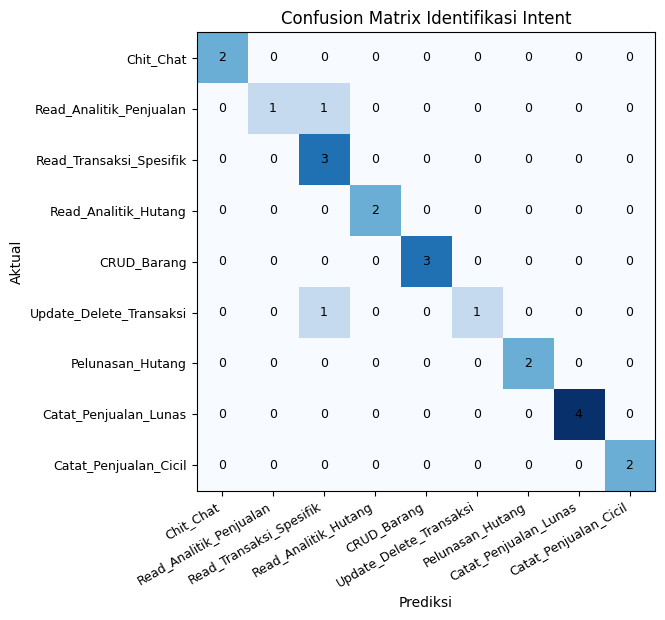

In [7]:
# Membuat visualisasi confusion matrix intent menggunakan heatmap.
plot_confusion_heatmap(df_cm_intent, title='Confusion Matrix Identifikasi Intent', cmap='Blues')

## Bagian 5. Evaluasi Ekstraksi Entitas

Evaluasi ekstraksi entitas dilakukan dengan membandingkan seluruh entitas ground truth dan hasil prediksi pada tingkat slot-value exact match. Setiap pasangan entitas dinilai `Benar` jika nilai prediksi sama persis dengan ground truth, dan `Salah` jika berbeda.

In [8]:
# Menentukan field entitas yang dievaluasi.
field_entitas = ['TANGGAL', 'NAMA', 'BARANG', 'JUMLAH', 'SATUAN']

# Menyusun tabel perbandingan entity-level antara ground truth dan prediksi.
baris_entitas = []
for _, gt_row in df_ground_truth.iterrows():
    pred_row = df_prediksi[df_prediksi['item_id'] == gt_row['item_id']].iloc[0]
    for field in field_entitas:
        nilai_gt = gt_row[field]
        nilai_pred = pred_row[field]
        cocok = str(nilai_gt).strip().lower() == str(nilai_pred).strip().lower()
        baris_entitas.append({
            'item_id': gt_row['item_id'],
            'field': field,
            'ground_truth': nilai_gt,
            'prediksi': nilai_pred,
            'label_aktual': 'Benar',
            'label_prediksi': 'Benar' if cocok else 'Salah'
        })

# Mengubah hasil perbandingan entitas menjadi DataFrame.
df_perbandingan_entitas = pd.DataFrame(baris_entitas)
df_perbandingan_entitas

,item_id,field,ground_truth,prediksi,label_aktual,label_prediksi
0,1,TANGGAL,None,None,Benar,Benar
1,1,NAMA,None,None,Benar,Benar
2,1,BARANG,None,None,Benar,Benar
3,1,JUMLAH,None,None,Benar,Benar
4,1,SATUAN,None,None,Benar,Benar
...,...,...,...,...,...,...
105,22,TANGGAL,None,None,Benar,Benar
106,22,NAMA,Pak Andi,Pak Andi,Benar,Benar
107,22,BARANG,None,None,Benar,Benar
108,22,JUMLAH,None,None,Benar,Benar


In [9]:
# Mengambil label aktual dan label prediksi untuk evaluasi ekstraksi entitas.
y_true_entitas = df_perbandingan_entitas['label_aktual']
y_pred_entitas = df_perbandingan_entitas['label_prediksi']

# Menentukan label evaluasi agar confusion matrix konsisten.
label_entitas = ['Benar', 'Salah']

# Menghitung confusion matrix ekstraksi entitas.
cm_entitas = confusion_matrix(y_true_entitas, y_pred_entitas, labels=label_entitas)

# Mengubah confusion matrix ekstraksi entitas menjadi DataFrame.
df_cm_entitas = pd.DataFrame(cm_entitas, index=label_entitas, columns=label_entitas)
df_cm_entitas

,Benar,Salah
Benar,108,2
Salah,0,0


In [10]:
# Menghitung metrik evaluasi ekstraksi entitas menggunakan scikit-learn.
accuracy_entitas = accuracy_score(y_true_entitas, y_pred_entitas)
precision_entitas = precision_score(y_true_entitas, y_pred_entitas, pos_label='Benar', average='binary', zero_division=0)
recall_entitas = recall_score(y_true_entitas, y_pred_entitas, pos_label='Benar', average='binary', zero_division=0)
f1_entitas = f1_score(y_true_entitas, y_pred_entitas, pos_label='Benar', average='binary', zero_division=0)

# Menyusun tabel hasil evaluasi ekstraksi entitas.
df_metrik_entitas = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Nilai': [accuracy_entitas, precision_entitas, recall_entitas, f1_entitas]
})
df_metrik_entitas

,Metrik,Nilai
0,Accuracy,0.981818
1,Precision,1.000000
2,Recall,0.981818
3,F1-score,0.990826


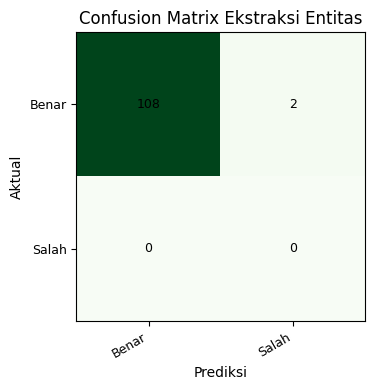

In [11]:
# Membuat visualisasi confusion matrix ekstraksi entitas menggunakan heatmap.
plot_confusion_heatmap(df_cm_entitas, title='Confusion Matrix Ekstraksi Entitas', cmap='Greens')

## Bagian 6. Tabel Evaluasi Akhir

Bagian ini merangkum seluruh hasil evaluasi untuk identifikasi intent dan ekstraksi entitas.

In [12]:
# Menyusun tabel evaluasi akhir agar siap digunakan sebagai dokumentasi skripsi.
df_evaluasi_akhir = pd.DataFrame({
    'Komponen': ['Identifikasi Intent', 'Ekstraksi Entitas'],
    'Accuracy': [accuracy_intent, accuracy_entitas],
    'Precision': [precision_intent, precision_entitas],
    'Recall': [recall_intent, recall_entitas],
    'F1-score': [f1_intent, f1_entitas]
})

# Mengubah angka menjadi persentase dua digit desimal agar lebih rapi.
df_evaluasi_persen = df_evaluasi_akhir.copy()
for kolom in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    df_evaluasi_persen[kolom] = (df_evaluasi_persen[kolom] * 100).round(2)

df_evaluasi_persen

,Komponen,Accuracy,Precision,Recall,F1-score
0,Identifikasi Intent,90.91,94.55,90.91,90.53
1,Ekstraksi Entitas,98.18,100.00,98.18,99.08


## Bagian 7. Kesimpulan Otomatis

Kesimpulan berikut dibuat secara otomatis berdasarkan nilai evaluasi yang dihasilkan.

In [13]:
# Menghitung jumlah entitas yang cocok dan tidak cocok untuk bahan kesimpulan otomatis.
jumlah_entitas_benar = int((df_perbandingan_entitas['label_prediksi'] == 'Benar').sum())
jumlah_entitas_salah = int((df_perbandingan_entitas['label_prediksi'] == 'Salah').sum())

# Menyusun kesimpulan otomatis berdasarkan hasil evaluasi sistem.
if accuracy_intent == 1.0 and accuracy_entitas == 1.0:
    kesimpulan = (
        'Hasil pengujian menunjukkan bahwa sistem berhasil mengidentifikasi intent dan mengekstraksi seluruh entitas '
        'dengan benar sehingga diperoleh nilai Accuracy, Precision, Recall, dan F1-score sebesar 100%. '
        'Dengan demikian, performa sistem pada data uji ini tergolong sangat baik.'
    )
else:
    kesimpulan = (
        f'Hasil pengujian menunjukkan bahwa sistem berhasil mengidentifikasi intent dengan Accuracy sebesar {accuracy_intent * 100:.2f}%. '
        f'Pada ekstraksi entitas, sistem memperoleh Accuracy {accuracy_entitas * 100:.2f}%, Precision {precision_entitas * 100:.2f}%, '
        f'Recall {recall_entitas * 100:.2f}%, dan F1-score {f1_entitas * 100:.2f}%. '
        f'Terdapat {jumlah_entitas_salah} entitas yang belum sesuai dari total {len(df_perbandingan_entitas)} entitas yang diuji.'
    )

# Menampilkan kesimpulan otomatis.
print(kesimpulan)

Hasil pengujian menunjukkan bahwa sistem berhasil mengidentifikasi intent dengan Accuracy sebesar 90.91%. Pada ekstraksi entitas, sistem memperoleh Accuracy 98.18%, Precision 100.00%, Recall 98.18%, dan F1-score 99.08%. Terdapat 2 entitas yang belum sesuai dari total 110 entitas yang diuji.
